<h1>DSCI 100 Final Project</h1>
<h3>Section 008 Group 19</h3>
<h5>Name: Camille S, Chloe Lin, Erica, Seerat Waraich</h5>

<h2>Introduction:</h2>
general question and specfic question. Basic explaination of what wrangling we will do, and possible issues.

<h2>Method & Results:</h2>
<h3>1. Load Data</h3>

In [30]:
#cell for loading packages
library(tidyverse)
library(tidymodels)
library(repr)
library(ggplot2)
library(themis)

In [31]:
url <- "https://raw.githubusercontent.com/camillesnyder/Final-Project/refs/heads/main/players.csv"
download.file( url, destfile = "players.csv")
players_data <- read_csv("players.csv")

head(players_data)

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21
Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17


<h3>2. Data Cleaning and Wrangling</h3>

In [35]:
#wrangling data by changing experience, subscribe to a numerical vector so straight-line calculations can be performed
#selecting played_hours vector, experience vector, and people who identify as male as predictors, and subscribe variable as the response
players_wrang <- players_data|>
    select(played_hours, experience, subscribe)|>
    mutate( experience = as_factor(experience))|>
    mutate( experience = fct_recode(experience,
                                    "1" = "Beginner",
                                    "2" = "Amateur",
                                    "3" = "Regular",
                                    "4" = "Veteran",
                                    "5" = "Pro"))|>
    mutate(experience = as.numeric(experience))|>
    mutate(subscribe = as_factor(subscribe))

dim(players_wrang)

[1] 196   3

### 3. Data Summary

#### players_data:

In [36]:
summary(players_data)

  experience        subscribe       hashedEmail         played_hours    
 Length:196         Mode :logical   Length:196         Min.   :  0.000  
 Class :character   FALSE:52        Class :character   1st Qu.:  0.000  
 Mode  :character   TRUE :144       Mode  :character   Median :  0.100  
                                                       Mean   :  5.846  
                                                       3rd Qu.:  0.600  
                                                       Max.   :223.100  
                                                                        
     name              gender               Age       
 Length:196         Length:196         Min.   : 9.00  
 Class :character   Class :character   1st Qu.:17.00  
 Mode  :character   Mode  :character   Median :19.00  
                                       Mean   :21.14  
                                       3rd Qu.:22.75  
                                       Max.   :58.00  
                               

|           |          |          |
| :-------- | :------- | :------- |
| **experience**  | character | players' experience levels in-game classified into levels: “Amateur”, “Beginner”, “Pro”, “Regular”, “Veteran” |
| **subscribe** |logical |  whether players subscribe to a game-related newsletter, indicated with TRUE and FALSE     |
| **hashedEmail**    |character | players’ email address    |
| **played_hours**      |numerical | players’ total playing durations (in hours) |
| **name**              |character |players' names|
| **gender**            |character | players' gender |
| **Age**               |numerical | players' age|

#### Players' Subscription Number

|[subscribe] | Counts |
| :----: | :-----: | 
|  **FALSE** | **TRUE** |
| 52 | 144  | 

This shows the number of players who subscribed to the game-related newsletter and those who did not. This helps identify whether the classes are balanced or imbalanced.

#### Players' Experience Levels Counts

In [53]:
players_data |> count(experience)

experience,n
<chr>,<int>
Amateur,63
Beginner,35
Pro,14
Regular,36
Veteran,48


This shows the number of players in each experience levels in-game.

#### Subscription Rate of Players

In [54]:
# Subscription Rate of players
proportion_of_subscribed <- players_data|>
    summarize(proportion_subscribed = sum(subscribe == "TRUE")/196)

proportion_of_subscribed

proportion_subscribed
<dbl>
0.7346939


#### Mean of [experience] & [subscribe]

In [55]:
# Mean of [experience] & [subscribe]
player_avgs <- players_wrang|>
    summarize(mean_experience = mean(experience),
              mean_played_hrs = mean(played_hours))

player_avgs

mean_experience,mean_played_hrs
<dbl>,<dbl>
3.153061,5.845918


### 4. Visualization of the Dataset
In this section, we explore the variables that may relate to newsletter subscription, including basic summaries and visualizations. No modeling is performed here.

#### Fig. 1 - Subscription Rate by Experience Level

The table shows the subscription rate of players with different experience levels.
\
There are more subscribers than non-subscribers in this dataset, which means the classes are not perfectly balanced, it is important to keep in mind for modelling because unequal class sizes may influence some methods while doing prediction.

#### Fig. 2 - Players' Experience Levels Distribution

Warning message in geom_histogram(stat = "count"):
“Ignoring unknown parameters: `binwidth`, `bins`, and `pad`”


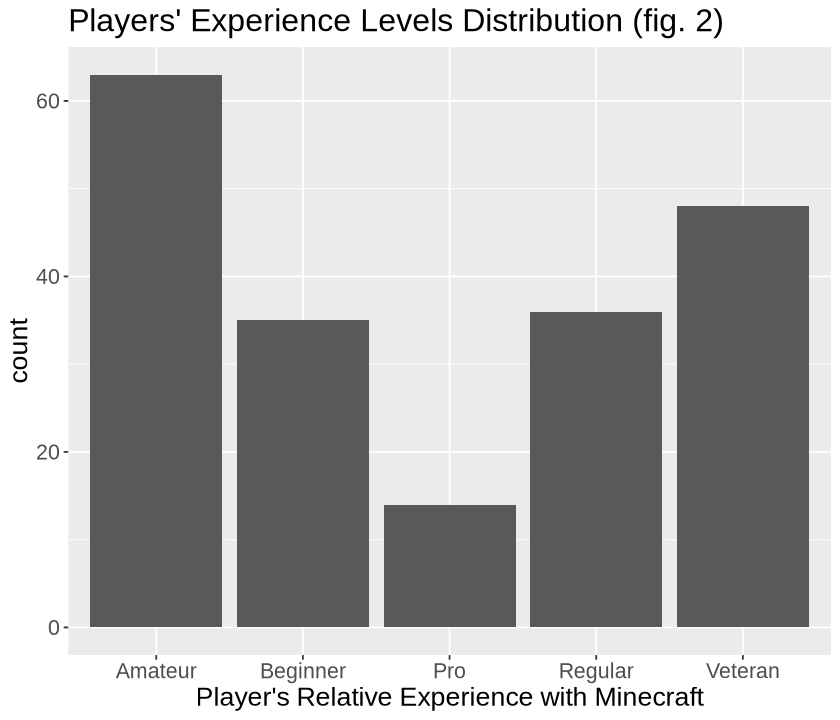

In [49]:
options(repr.plot.height = 6, repr.plot.width = 7)
experience_distribution_before_wrang <- players_data |>
    ggplot( aes(x= experience))+
    geom_histogram(stat = "count")+
    labs(x= "Player's Relative Experience with Minecraft",
        title = "Players' Experience Levels Distribution (fig. 2)") +
    theme( text = element_text(size = 16))

experience_distribution_before_wrang

In [50]:
# [explain]

### 5. Exploratory Data Analysis (EDA)

In [24]:
#do knn classification given played hrs obs and experience level obs to predict subscription status
#train on 75% and test on 25%
set.seed(27)

players_split <- players_wrang|>
    initial_split( prop = 0.75, strata = subscribe)

players_train <- training(players_split)

players_test<- testing(players_split)

#model specification
knn_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = tune())|>
            set_engine("kknn")|>
            set_mode("classification")

k_vals<- tibble(neighbors = seq(from = 1, to = 40, by = 2))
#balance data by stepping up the sample of unsubscribed male players
# ups_recipe <- recipe(subscribe ~ played_hours + experience, data = players_train)|>
#       step_normalize(all_predictors())|>
#     step_upsample(subscribe, over_ratio = 1, skip = FALSE)|>
#     prep()

# players_train <- bake(ups_recipe, players_train)
players_recipe <- recipe(subscribe ~ played_hours + experience, data = players_train)|>
      step_normalize(all_predictors())

players_vfold <- vfold_cv(players_train, v = 10, strata = subscribe)

players_results <- workflow()|>
    add_recipe(players_recipe)|>
    add_model(knn_spec)|>
    tune_grid(resamples = players_vfold, grid = k_vals)|>
    collect_metrics()|>
    filter(.metric == "accuracy")

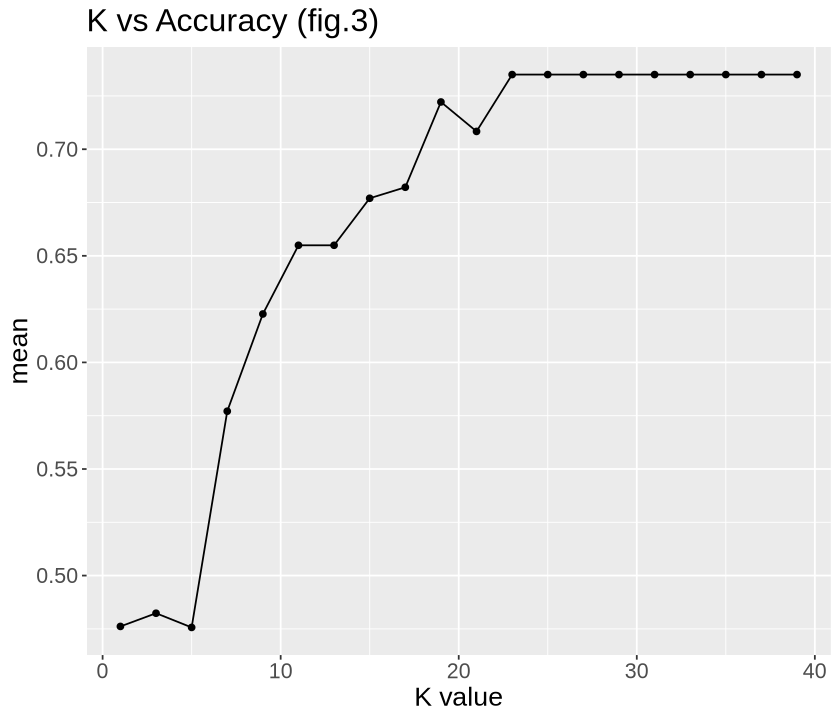

In [56]:
options(repr.plot.height = 6)
K_vs_accuracy <- ggplot(players_results, aes( x= neighbors, y = mean))+
    geom_point()+
    geom_line()+
    labs( x = "K value", title = "K vs Accuracy (fig.3)")+
    theme(text = element_text(size = 16))

K_vs_accuracy

In [57]:
#retrain model based on best parameter value k=19
players_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = 21)|>
    set_engine("kknn")|>
    set_mode("classification")

#test new model on test data 
players_fit <- workflow()|>
    add_recipe(players_recipe)|>
    add_model(players_spec)|>
    fit(data = players_train)

test_predictions <- predict(players_fit, players_test)|>
    bind_cols(players_test)|>
    metrics(truth = subscribe, estimate = .pred_class)|>
    filter(.metric == "accuracy")

test_predictions

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.6530612


Basically, the results mean nothing because the accuracy of the predictions is about the same as the proportion of people who are subscribed to the newsletter in the data set with only male players included.